# Generation script to prepare regrounding for evaluation 

# Look at extractslices for a script

In [2]:
import json
import pandas as pd
from huggingface_hub import hf_hub_download


# Load the dataset.json file
with open("/vol/idea_longterm/datasets/CT-RATE-Segmentations/dataset.json", "r") as f:
    data = json.load(f)

# Extract all 'name' fields
names = [entry["name"] for entry in data["train"]]
names += [entry["name"] for entry in data["train"]]
names[:3]

/vol/ideadata/ed52egek/miniconda/envs/syneverything/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['train_1741_b_2.nii.gz', 'train_1935_a_1.nii.gz', 'train_1591_f_2.nii.gz']

In [3]:
data["test"][0]

{'name': 'train_13195_a_1.nii.gz',
 'findings': {'0': 'Subpleural ground glass opacity in the posterobasal segment of the right lower lobe',
  '1': 'Subpleural ground glass opacity in the anterobasal segment of the left lower lobe'},
 'shape': [512, 512, 202],
 'categories': {'0': '2c', '1': '2c'},
 'protocol': 'test'}

In [4]:
# Create lists to store the data
names = []
finding_keys = []
findings = []
splits = []
categories = []

# Extract data from train entries
for split in ["train", "val", "test"]:
    for entry in data[split]:
        name = entry["name"]
        for key, finding in entry["findings"].items():
            names.append(name)
            finding_keys.append(key)
            findings.append(finding)
            splits.append(split)
            categories.append(entry["categories"][key])

# Create dataframe
df = pd.DataFrame({
    "name": names,
    "finding_key": finding_keys, 
    "finding": findings,
    "categories": categories,
    "Split": splits
})

df.to_csv("ctflow.csv")
df

,name,finding_key,finding,categories,Split
0,train_1741_b_2.nii.gz,0,Irregularly circumscribed nodular consolidatio...,2b,train
1,train_1935_a_1.nii.gz,0,Segmental and subsegmental peribronchial thick...,1a,train
2,train_1935_a_1.nii.gz,1,Mosaic attenuation pattern in both lungs,2c,train
3,train_1935_a_1.nii.gz,2,Reticulonodular density increases in both lung...,1d,train
4,train_1935_a_1.nii.gz,3,Paraseptal emphysema in both lung apices,1c,train
...,...,...,...,...,...
8023,train_13051_a_1.nii.gz,3,Linear atelectasis areas in the left upper lob...,2a,test
8024,train_13051_a_1.nii.gz,4,Significant increase in dependent density in b...,2b,test
8025,train_13240_b_2.nii.gz,0,Diffuse ground glass opacities in both lungs h...,2c,test
8026,train_13240_b_2.nii.gz,1,Subcentimeter nonspecific stable nodules in bo...,2d,test


In [5]:
df["Split"].value_counts()

Split
train    7687
test      226
val       115
Name: count, dtype: int64

In [36]:
single_label_df = pd.read_csv("/vol/ideadata/ed52egek/pycharm/longtail/datasets/ctflow/ctrate_slices_final_singlelabel.csv").drop(columns={"Unnamed: 0"})

classes = list(df.categories.unique())  + ["No Finding"]


single_label_df["image"] = single_label_df["path"].apply(lambda x: "_".join(x.split("_")[:5]) + ".nii.gz")
single_label_df["image"]


0         ctflow_slices/train_1741_b_2.nii.gz
1         ctflow_slices/train_1741_b_2.nii.gz
2         ctflow_slices/train_1935_a_1.nii.gz
3         ctflow_slices/train_1935_a_1.nii.gz
4         ctflow_slices/train_1935_a_1.nii.gz
                         ...                 
22300    ctflow_slices/train_13316_a_2.nii.gz
22301    ctflow_slices/train_13339_a_1.nii.gz
22302    ctflow_slices/train_13339_a_1.nii.gz
22303    ctflow_slices/train_13339_a_1.nii.gz
22304    ctflow_slices/train_13339_a_1.nii.gz
Name: image, Length: 22305, dtype: object

In [42]:
name =  single_label_df.iloc[2]["image"].split("/")[1]
print(name)

#2,ctflow_slices/train_1935_a_1_f123.nii.gz.png,TEST,1935,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,/vol/idea_longterm/ed52egek/CTFlow/slices/ctflow_slices/train_1935_a_1_f123.nii.gz.png,Bronchial wall thickening
#3,ctflow_slices/train_1935_a_1_f134.nii.gz.png,TEST,1935,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,/vol/idea_longterm/ed52egek/CTFlow/slices/ctflow_slices/train_1935_a_1_f134.nii.gz.png,Bronchial wall thickening
cur_volume_df = df[df["name"] == name]
cur_volume_df

train_1935_a_1.nii.gz


,name,finding_key,finding,categories,Split
1,train_1935_a_1.nii.gz,0,Segmental and subsegmental peribronchial thick...,1a,train
2,train_1935_a_1.nii.gz,1,Mosaic attenuation pattern in both lungs,2c,train
3,train_1935_a_1.nii.gz,2,Reticulonodular density increases in both lung...,1d,train
4,train_1935_a_1.nii.gz,3,Paraseptal emphysema in both lung apices,1c,train
5,train_1935_a_1.nii.gz,4,Several subcentimeter nonspecific pulmonary no...,2d,train


In [66]:
from tqdm import tqdm 
impressions = []

for cur_idx in tqdm(range(len(single_label_df))): 
    cur = single_label_df.iloc[cur_idx]
    cur_name = cur["image"].split("/")[1] 
    slice_category = cur[classes].idxmax()
    if slice_category == "No Finding":
        impressions.append("No Finding")
    else: 
        cur_volume_df = df[df["name"] == cur_name]
        finding_candidates = cur_volume_df[cur_volume_df["categories"] == slice_category]

        if len(finding_candidates) > 1: 
            impressions.append("Multiple")
            continue

        if len(finding_candidates) < 1: 
            raise ValueError("Multiple")

        impressions.append(finding_candidates.iloc[0]["finding"])


single_label_df["impression"] = impressions
single_label_df.to_csv("ctrates_slices_final_withimpressions.csv")

100%|██████████| 22305/22305 [00:16<00:00, 1326.88it/s]


In [117]:
single_label_df

,path,Split,id,No Finding,1a,1b,1c,1d,1e,1f,...,2c,2d,2e,2f,2g,2h,FileName,Finding Labels,image,impression
0,ctflow_slices/train_1741_b_2_f077.nii.gz.png,TEST,1741,0,0,0,0,0,0,0,...,0,0,0,0,0,0,/vol/idea_longterm/ed52egek/CTFlow/slices/ctfl...,"Atelectasis, consolidation",ctflow_slices/train_1741_b_2.nii.gz,Irregularly circumscribed nodular consolidatio...
1,ctflow_slices/train_1741_b_2_f021.nii.gz.png,TEST,1741,1,0,0,0,0,0,0,...,0,0,0,0,0,0,/vol/idea_longterm/ed52egek/CTFlow/slices/ctfl...,No Finding,ctflow_slices/train_1741_b_2.nii.gz,No Finding
2,ctflow_slices/train_1935_a_1_f123.nii.gz.png,TEST,1935,0,1,0,0,0,0,0,...,0,0,0,0,0,0,/vol/idea_longterm/ed52egek/CTFlow/slices/ctfl...,Bronchial wall thickening,ctflow_slices/train_1935_a_1.nii.gz,Segmental and subsegmental peribronchial thick...
3,ctflow_slices/train_1935_a_1_f134.nii.gz.png,TEST,1935,0,1,0,0,0,0,0,...,0,0,0,0,0,0,/vol/idea_longterm/ed52egek/CTFlow/slices/ctfl...,Bronchial wall thickening,ctflow_slices/train_1935_a_1.nii.gz,Segmental and subsegmental peribronchial thick...
4,ctflow_slices/train_1935_a_1_f102.nii.gz.png,TEST,1935,0,0,0,0,0,0,0,...,1,0,0,0,0,0,/vol/idea_longterm/ed52egek/CTFlow/slices/ctfl...,Groundglass opacity,ctflow_slices/train_1935_a_1.nii.gz,Mosaic attenuation pattern in both lungs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22300,ctflow_slices/train_13316_a_2_f016.nii.gz.png,TRAIN,13316,1,0,0,0,0,0,0,...,0,0,0,0,0,0,/vol/idea_longterm/ed52egek/CTFlow/slices/ctfl...,No Finding,ctflow_slices/train_13316_a_2.nii.gz,No Finding
22301,ctflow_slices/train_13339_a_1_f226.nii.gz.png,TRAIN,13339,0,0,0,0,0,0,0,...,0,1,0,0,0,0,/vol/idea_longterm/ed52egek/CTFlow/slices/ctfl...,Pulmonary nodules/masses,ctflow_slices/train_13339_a_1.nii.gz,Multiple
22302,ctflow_slices/train_13339_a_1_f164.nii.gz.png,TRAIN,13339,0,0,0,0,0,0,0,...,0,1,0,0,0,0,/vol/idea_longterm/ed52egek/CTFlow/slices/ctfl...,Pulmonary nodules/masses,ctflow_slices/train_13339_a_1.nii.gz,Multiple
22303,ctflow_slices/train_13339_a_1_f084.nii.gz.png,TRAIN,13339,1,0,0,0,0,0,0,...,0,0,0,0,0,0,/vol/idea_longterm/ed52egek/CTFlow/slices/ctfl...,No Finding,ctflow_slices/train_13339_a_1.nii.gz,No Finding


In [126]:
for i, row in tqdm(single_label_df.iterrows()):
    if row["impression"] != "Multiple": 
        continue
    #print(row)
    frame = row["path"].split("_")[-1].split(".")[0].lstrip("f")
    cur_name = row["image"].split("/")[1] 
    #print(frame)
    #print(cur_name)
    gt_mask = load_gt_mask(cur_name, None)

    #finding_key = 
    cur_df = df[df["name"] == cur_name]
    finding_key = gt_mask[..., int(frame)].max(dim=1).values.max(dim=1).values.argmax().item()
    impression = cur_df[cur_df["finding_key"] == str(finding_key)]
    single_label_df.loc[i, "impression"] = impression["finding"].item()



single_label_df.to_csv("ctrates_slices_final_withimpressions_final.csv")

156it [00:27,  5.71it/s]


KeyboardInterrupt: 

int

,name,finding_key,finding,categories,Split
6,train_1591_f_2.nii.gz,0,Regression of consolidation areas in the middl...,2b,train
7,train_1591_f_2.nii.gz,1,Atelectatic changes in the posterobasal segmen...,2b,train
8,train_1591_f_2.nii.gz,2,Fibroatelectatic changes in the anterolateral ...,2b,train
9,train_1591_f_2.nii.gz,3,Newly revealed focal acinar infiltration areas...,2b,train
10,train_1591_f_2.nii.gz,4,Fibroatelectatic changes in both lungs,2b,train


'Regression of consolidation areas in the middle lobe and lower lobes of the right lung compared to the previous examination'

In [110]:
df["name"] == cur_name

5

# Usage

In [7]:
from os.path import join
import torch 
import nibabel as nib
import pandas as pd
from pathlib import Path
import numpy as np

def load_gt_mask(path, finding_key=None): 
    from huggingface_hub import hf_hub_download
    repo_id = "rajpurkarlab/ReXGroundingCT"
    file_path = hf_hub_download(
        repo_id=repo_id,
        filename=f"segmentations/{path}",
        repo_type="dataset"
    )
    nifti_img = nib.load(file_path)
    nifti_data = nifti_img.get_fdata()
    if finding_key is None:
        # Sum all finding key masks together
        return torch.Tensor(nifti_data).clip(0, 1)
    else:
        return torch.Tensor(nifti_data[int(finding_key)]).clip(0, 1)

def name_to_path(name):
    # Convert name from grounding.csv to full path
    parts = name.split('_')  # e.g. train_1741_b_2.nii.gz -> ['train', '1741', 'b', '2.nii.gz']
    folder = f"{parts[0]}_{parts[1]}"  # train_1741
    subfolder = f"{folder}_{parts[2]}"  # train_1741_b
    path = Path(f"/vol/idea_longterm/datasets/CT-RATE/dataset/{parts[0]}/{folder}/{subfolder}/{name}")
    return path

def load_gt_in(name): 
    path = name_to_path(name)
    img = nib.load(str(path), mmap=True)
    vol = img.get_fdata(dtype=np.float32)
    return torch.tensor(vol)


pd.read_csv("ctflow.csv")

,Unnamed: 0,name,finding_key,finding,categories,Split
0,0,train_1741_b_2.nii.gz,0,Irregularly circumscribed nodular consolidatio...,2b,train
1,1,train_1935_a_1.nii.gz,0,Segmental and subsegmental peribronchial thick...,1a,train
2,2,train_1935_a_1.nii.gz,1,Mosaic attenuation pattern in both lungs,2c,train
3,3,train_1935_a_1.nii.gz,2,Reticulonodular density increases in both lung...,1d,train
4,4,train_1935_a_1.nii.gz,3,Paraseptal emphysema in both lung apices,1c,train
...,...,...,...,...,...,...
8023,8023,train_13051_a_1.nii.gz,3,Linear atelectasis areas in the left upper lob...,2a,test
8024,8024,train_13051_a_1.nii.gz,4,Significant increase in dependent density in b...,2b,test
8025,8025,train_13240_b_2.nii.gz,0,Diffuse ground glass opacities in both lungs h...,2c,test
8026,8026,train_13240_b_2.nii.gz,1,Subcentimeter nonspecific stable nodules in bo...,2d,test


In [8]:
from scipy import ndimage as ndi

def bbox_from_mask(mask: np.ndarray, connectivity: int = 1, min_voxels: int = 40):
    if mask.ndim != 3:
        raise ValueError(f"Expected a 3D mask (Z,Y,X), got shape {mask.shape}")

    if mask.shape[0] == mask.shape[1] and mask.shape[1] != mask.shape[2]:
        mask = mask.transpose((2, 0, 1))


    structure = ndi.generate_binary_structure(3, connectivity)
    labeled, num = ndi.label(mask, structure=structure)
    if num == 0:
        return []

    # Fast per-label voxel counts to filter tiny components
    counts = np.bincount(labeled.ravel())
    # Slices are half-open: slice.start .. slice.stop (exclusive)
    slices = ndi.find_objects(labeled)

    boxes = []
    for lbl, slc in enumerate(slices, start=1):
        if slc is None:
            continue
        if counts[lbl] < min_voxels:
            continue
        zslice, yslice, xslice = slc
        x_min, y_min, z_min = xslice.start, yslice.start, zslice.start
        dx = xslice.stop - xslice.start
        dy = yslice.stop - yslice.start
        dz = zslice.stop - zslice.start
        boxes.append((x_min, y_min, z_min, dx, dy, dz))
    return boxes


idx = 10  
#finding_key = df.iloc[idx]["finding_key"]
path = df.iloc[idx]["name"]


gt_mask = load_gt_mask(path, None)
masks = [bbox_from_mask(gt_mask[i].transpose(2, 1).transpose(0, 1)) for i in range(len(gt_mask))]
print(gt_mask.size())
print(gt_mask.sum(axis=0).size())
df.iloc[idx]

torch.Size([5, 512, 512, 466])
torch.Size([512, 512, 466])


name                            train_1591_f_2.nii.gz
finding_key                                         4
finding        Fibroatelectatic changes in both lungs
categories                                         2b
Split                                           train
Name: 10, dtype: object

In [9]:
path = "train_1935_a_1"
path = path + ".nii.gz"
load_gt_mask(path).size()

torch.Size([5, 512, 512, 264])

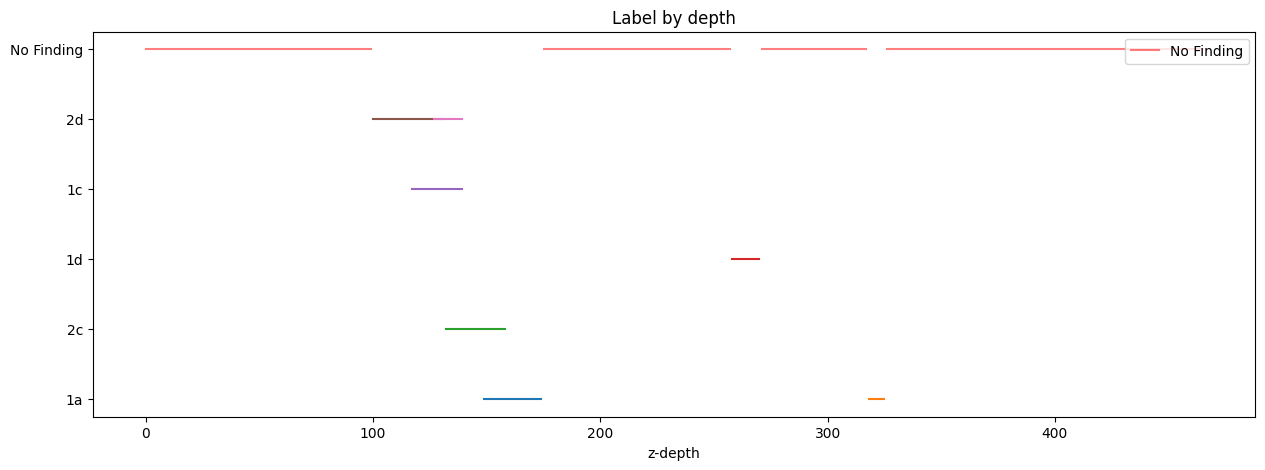

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def contiguous_runs(mask_bool):
    """Return [(start, end), ...] for contiguous True runs in a 1D boolean array."""
    a = np.asarray(mask_bool, dtype=bool)
    if a.size == 0:
        return []
    diffs = np.diff(np.pad(a.astype(int), (1, 1)))
    starts = np.where(diffs == 1)[0]
    ends   = np.where(diffs == -1)[0]
    return list(zip(starts, ends))

def plot_findings_by_depth(gt_mask, masks, df, path):
    """Plot findings and no-finding regions by z-depth.
    
    Args:
        gt_mask: Ground truth mask tensor
        masks: List of bounding boxes for each finding
        df: DataFrame containing finding metadata
        path: Path/name of the current case
    """
    z_max = int(gt_mask.size()[-1])
    fig, axs = plt.subplots(figsize=(15, 5))

    # Track where any finding is present
    has_finding = np.zeros(z_max, dtype=bool)

    # Plot findings
    for i, masks_ in enumerate(masks):
        row = df[(df["name"] == path) & (df["finding_key"] == str(i))]
        category = row["categories"].iloc[0] if len(row) else f"cat_{i}"

        for mask in masks_:
            z_start = int(mask[2])
            length  = int(mask[5])
            z_stop  = min(z_start + length, z_max)
            if z_start >= z_stop:
                continue
            has_finding[z_start:z_stop] = True
            axs.plot(np.arange(z_start, z_stop),
                     [category] * (z_stop - z_start))

    # Split zeros into contiguous segments and plot each separately
    no_runs = contiguous_runs(~has_finding)
    for j, (s, e) in enumerate(no_runs):
        axs.plot(np.arange(s, e),
                 ["No Finding"] * (e - s),
                 c="red",
                 alpha=0.5,
                 label="No Finding" if j == 0 else None)

    axs.set_title("Label by depth")
    axs.set_xlabel("z-depth")
    axs.legend(loc="upper right")
    plt.show()

# Call the function with current variables
plot_findings_by_depth(gt_mask, masks, df, path)